## Plot scale scaling

In [5]:
from __future__ import annotations

import json
import re
from pathlib import Path

try:
    import pandas as pd
except ImportError:
    pd = None

try:
    import matplotlib.pyplot as plt
except ImportError:
    plt = None

REPORTS_ROOT = Path.cwd()

LOG_PATTERNS = {
    "world_size": re.compile(r"World Size:\s*(\d+)"),
    "output_dir": re.compile(r"Output directory:\s*(.+)"),
    "summary_path": re.compile(r"Benchmark summary:\s*(.+)"),
    "elapsed_seconds": re.compile(r"Measured time:\s*([\d.]+)s"),
    "samples_per_second_global": re.compile(r"Global throughput:\s*([\d.]+)\s+samples/s"),
    "samples_per_second_per_gpu": re.compile(r"Per-GPU throughput:\s*([\d.]+)\s+samples/s"),
    "optimizer_steps_per_second": re.compile(r"Optimizer step rate:\s*([\d.]+)\s+steps/s"),
    "global_tokens_per_sec": re.compile(r"Global token throughput:\s*([\d.]+)\s+tokens/s"),
    "average_loss": re.compile(r"Average loss:\s*([\d.]+)"),
}


def _search(pattern: re.Pattern[str], text: str, cast=None):
    match = pattern.search(text)
    if not match:
        return None
    value = match.group(1).strip()
    return cast(value) if cast else value


def read_benchmark_record(log_path: Path) -> dict:
    text = log_path.read_text(errors="replace")
    task_id = log_path.parent.name
    record = {
        "task_id": task_id,
        "log_path": str(log_path),
        "world_size": _search(LOG_PATTERNS["world_size"], text, int),
        "output_dir": _search(LOG_PATTERNS["output_dir"], text),
        "summary_path": _search(LOG_PATTERNS["summary_path"], text),
    }

    if record["summary_path"]:
        summary_path = Path(record["summary_path"])
    elif record["output_dir"]:
        summary_path = Path(record["output_dir"]) / "benchmark_summary.json"
    else:
        summary_path = None

    if summary_path and summary_path.exists():
        summary = json.loads(summary_path.read_text())
        record["summary_path"] = str(summary_path)
        record.update(summary)
    else:
        for key in (
            "elapsed_seconds",
            "samples_per_second_global",
            "samples_per_second_per_gpu",
            "optimizer_steps_per_second",
            "global_tokens_per_sec",
            "average_loss",
        ):
            record[key] = _search(LOG_PATTERNS[key], text, float)

    return record


records = [read_benchmark_record(path) for path in sorted(REPORTS_ROOT.glob("*/OneAstro-bench-*.out"))]
records = sorted(records, key=lambda row: (row["world_size"] is None, row["world_size"], row["task_id"]))

columns = [
    "task_id",
    "world_size",
    "samples_per_second_global",
    "global_tokens_per_sec",
]

if pd is not None:
    scale_df = pd.DataFrame(records)
    scale_view = scale_df[columns]
else:
    scale_df = records
    scale_view = [{column: row.get(column) for column in columns} for row in records]

scale_view

if pd is not None:
    print(
        scale_view[["world_size", "global_tokens_per_sec"]]
        .assign(global_tokens_per_sec=lambda df: df["global_tokens_per_sec"].round().astype("Int64"))
        .to_string(index=False)
    )
else:
    print([
        {
            "world_size": int(row["world_size"]) if row.get("world_size") is not None else None,
            "global_tokens_per_sec": int(round(row["global_tokens_per_sec"])) if row.get("global_tokens_per_sec") is not None else None,
        }
        for row in scale_view
    ])


 world_size  global_tokens_per_sec
          4                 159272
          8                 287765
         16                 531673
         32                 850487
         64                1122827
        128                1231944


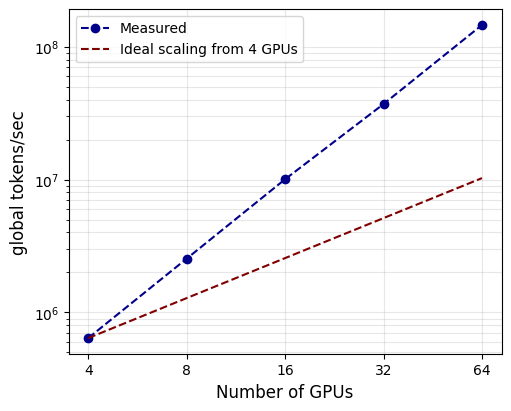

In [42]:
if plt is None:
    raise ImportError("matplotlib is not installed in the active notebook kernel")

if pd is not None:
    plot_df = scale_df.dropna(subset=["world_size"]).copy()
    world_sizes = plot_df["world_size"].tolist()
    global_tokens = plot_df["global_tokens_per_sec"].tolist()
else:
    plot_df = [row for row in scale_df if row.get("world_size") is not None]
    world_sizes = [row["world_size"] for row in plot_df]
    global_tokens = [row.get("global_tokens_per_sec") for row in plot_df]

valid_points = [
    (world_size, token_rate)
    for world_size, token_rate in zip(world_sizes, global_tokens)
    if token_rate is not None and token_rate > 0
]

if not valid_points:
    raise ValueError("No valid global_tokens_per_sec values found to plot")

x_values, y_values = zip(*valid_points)

baseline_world_size = 4
baseline_tokens = next((y for x, y in valid_points if x == baseline_world_size), None)
if baseline_tokens is None:
    raise ValueError("Could not find the baseline point at world_size=4")

ideal_y_values = [baseline_tokens * (x / baseline_world_size) for x in x_values]
efficiency_values = [
    (measured / ideal) * 100
    for measured, ideal in zip(y_values, ideal_y_values)
]

fig, axes = plt.subplots(1, 2, figsize=(10, 4), dpi=200, constrained_layout=True)

axes[0].plot(x_values, y_values, marker="o", linestyle="--", color="darkblue", label="Measured")
axes[0].plot(x_values, ideal_y_values, linestyle="--", color="maroon", label="Ideal scaling from 4 GPUs")
axes[0].set_xlabel("Number of GPUs", fontsize=12)
axes[0].set_ylabel("global tokens/sec", fontsize=12)
axes[0].set_xscale("log", base=2)
axes[0].set_yscale("log", base=10)
axes[0].set_xticks(list(x_values))
axes[0].get_xaxis().set_major_formatter(plt.ScalarFormatter())
axes[0].grid(True, which="both", alpha=0.3)
axes[0].legend()

axes[1].plot(x_values, efficiency_values, marker="o", linestyle="--", color="darkgreen")
axes[1].set_xlabel("Number of GPUs", fontsize=12)
axes[1].set_ylabel("Efficiency (%)", fontsize=12)
axes[1].set_xscale("log", base=2)
axes[1].set_xticks(list(x_values))
axes[1].get_xaxis().set_major_formatter(plt.ScalarFormatter())
axes[1].grid(True, which="both", alpha=0.3)

plt.show()
